**SECTION 1 — Installations**

In [ ]:
!pip install transformers accelerate gradio

**SECTION 2 — Imports**

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import gradio as gr

**Uploader du CSV dans Colab.**

In [6]:
df = pd.read_csv("données.csv",sep=";")
df.head()
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Code_region          3240 non-null   int64 
 1   annee                3240 non-null   int64 
 2   indicateur           3240 non-null   object
 3   unite_de_compte      3240 non-null   object
 4   nombre               3240 non-null   int64 
 5   taux_pour_mille      3240 non-null   object
 6   insee_pop            3240 non-null   int64 
 7   insee_pop_millesime  3240 non-null   int64 
 8   insee_log            3240 non-null   int64 
 9   insee_log_millesime  3240 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 253.3+ KB


In [7]:
df["indicateur"].unique()

array(['Homicides', "Tentatives d'homicide",
       'Violences physiques intrafamiliales',
       'Violences physiques hors cadre familial', 'Violences sexuelles',
       'Vols avec armes', 'Vols violents sans arme',
       'Vols sans violence contre des personnes',
       'Cambriolages de logement', 'Vols de véhicule',
       'Vols dans les véhicules', "Vols d'accessoires sur véhicules",
       'Destructions et dégradations volontaires', 'Usage de stupéfiants',
       'Usage de stupéfiants (AFD)', 'Usage de stupéfiants (hors AFD)',
       'Trafic de stupéfiants',
       'Escroqueries et fraudes aux moyens de paiement'], dtype=object)

**Créer SQLite**

In [8]:
# =========================
# IMPORT SQLITE
# =========================

import sqlite3

# =========================
# CRÉATION DE LA BASE SQLITE
# =========================

conn = sqlite3.connect("crime.db")

print("Base SQLite créée")

# =========================
# TRANSFORMATION DU DATAFRAME EN TABLE SQL
# =========================

df.to_sql(
    "crime",          # nom de la table SQL
    conn,             # connexion SQLite
    if_exists="replace",
    index=False
)

print("Table 'crime' créée avec succès")

# =========================
# TEST D'UNE REQUÊTE SQL
# =========================

query = """
SELECT *
FROM crime
LIMIT 5
"""

result = pd.read_sql(query, conn)

print(result)

Base SQLite créée
Table 'crime' créée avec succès
   Code_region  annee indicateur unite_de_compte  nombre taux_pour_mille  \
0            1   2016  Homicides         Victime      32       0,0811956   
1            2   2016  Homicides         Victime      18       0,0478113   
2            3   2016  Homicides         Victime      41       0,1522172   
3            4   2016  Homicides         Victime      14       0,0164141   
4            6   2016  Homicides         Victime      10       0,0389836   

   insee_pop  insee_pop_millesime  insee_log  insee_log_millesime  
0     394110                 2016     226105                 2016  
1     376480                 2016     211621                 2016  
2     269352                 2016      88454                 2016  
3     852924                 2016     363111                 2016  
4     256518                 2017      73880                 2017  


In [9]:
query = """
SELECT indicateur,
       SUM(nombre) AS total
FROM crime
GROUP BY indicateur
ORDER BY total DESC
"""

result = pd.read_sql(query, conn)

result

,indicateur,total
0,Vols sans violence contre des personnes,6516211
1,Destructions et dégradations volontaires,5663176
2,Escroqueries et fraudes aux moyens de paiement,3377324
3,Vols dans les véhicules,2522912
4,Usage de stupéfiants,2231073
5,Cambriolages de logement,2213230
6,Violences physiques hors cadre familial,1883943
7,Violences physiques intrafamiliales,1816969
8,Vols de véhicule,1382017
9,Usage de stupéfiants (hors AFD),1378231


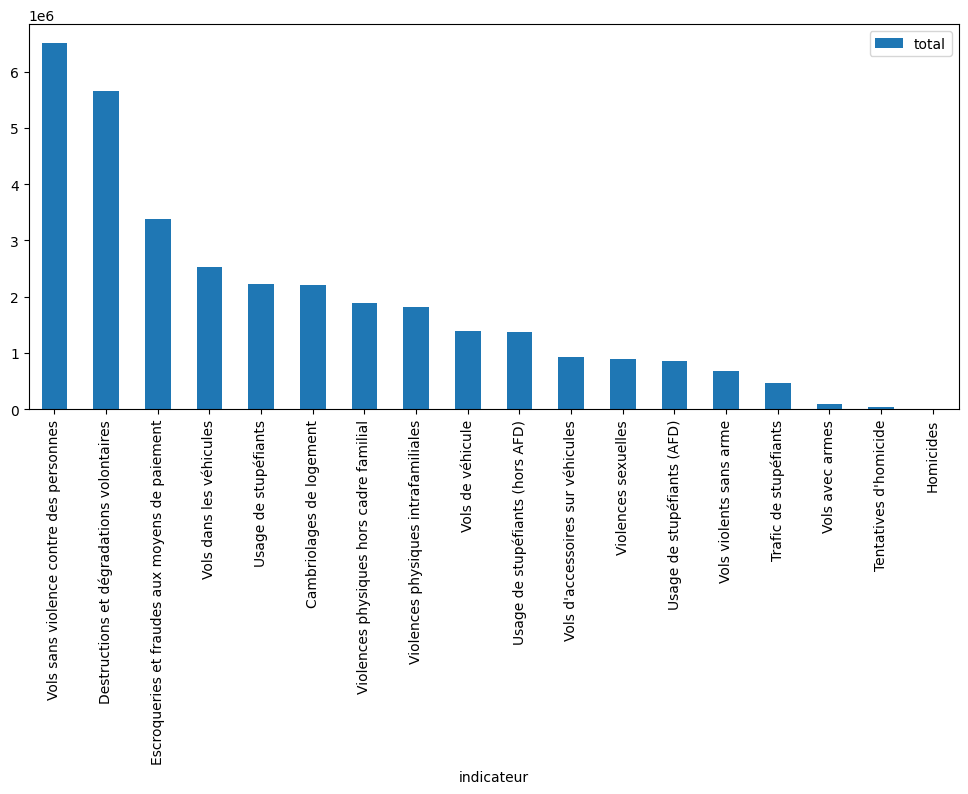

In [10]:
result.plot(
    x="indicateur",
    y="total",
    kind="bar",
    figsize=(12,5)
)

plt.xticks(rotation=90)

plt.show()

**CHARGER ET INSTALLER UN LLM LOCAL**

In [11]:
from transformers import pipeline

In [12]:
pipe = pipeline(
    "text-generation",
    model="TinyLlama/TinyLlama-1.1B-Chat-v1.0"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

In [20]:
prompt = """
Tu génères uniquement des requêtes SQL SQLite.

Table : crime

Colonnes :
- Code_region
- annee
- indicateur
- unite_de_compte
- nombre
- taux_pour_mille

Exemple :

Question :
Nombre total de cambriolages de logement en 2020

SQL :
SELECT SUM(nombre)
FROM crime
WHERE indicateur = 'Cambriolages de logement'
AND annee = 2020;

Maintenant :

Question :
Nombre total d'Homicides en 2016

SQL :
"""

In [23]:
response = pipe(
    prompt,
    max_new_tokens=40,
    return_full_text=False
)

generated_sql = response[0]["generated_text"]
generated_sql = generated_sql.split(";")[0] + ";"

print(generated_sql)

Both `max_new_tokens` (=40) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SELECT SUM(nombre)
FROM crime
WHERE indicateur = 'Homicides'
AND annee = 2016;
SELECT SUM(nombre)
FROM crime
WHERE indicateur = 'Homicides'
AND annee = 2016;


In [24]:
result = pd.read_sql(generated_sql, conn)

result

,SUM(nombre)
0,911


**AUTOMATISATION DES QUESTIONS-ÉTAPE 1 — Créer une fonction**

In [36]:
def ask_question(question):

    prompt = f"""
    Tu génères uniquement des requêtes SQL SQLite.

    Table : crime

    Colonnes :
    - Code_region
    - annee
    - indicateur
    - unite_de_compte
    - nombre
    - taux_pour_mille

    Valeurs possibles pour indicateur :
    - Homicides
    - Violences sexuelles
    - Vols de véhicule
    - Cambriolages de logement

    Exemple :

    Question :
    Nombre total de cambriolages de logement en 2020

    SQL :
    SELECT SUM(nombre)
    FROM crime
    WHERE indicateur = 'Cambriolages de logement'
    AND annee = 2020;

    Maintenant :

    Question :
    {question}

    SQL :
    """

    response = pipe(
        prompt,
        max_new_tokens=40,
        return_full_text=False
    )

    generated_sql = response[0]["generated_text"]

    generated_sql = generated_sql.split(";")[0] + ";"

    print("SQL généré :")
    print(generated_sql)

    try:

        result = pd.read_sql(generated_sql, conn)

        print(result)

        if result.iloc[0,0] is None:
            print("Aucun résultat trouvé")
            return result

        result.plot(kind="bar")

        plt.show()

        return result

    except Exception as e:

        print("Erreur SQL :")
        print(e)

        return "Erreur dans la génération SQL"

**TEST DE LA FONCTION**

Both `max_new_tokens` (=40) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


SQL généré :

    SELECT SUM(nombre)
    FROM crime
    WHERE indicateur = 'Vols de véhicule'
    AND annee = 2022;
   SUM(nombre)
0       133136


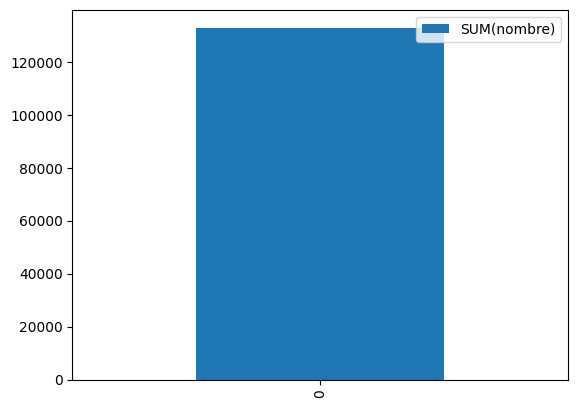

,SUM(nombre)
0,133136


In [37]:
ask_question(
    "Nombre total de vols de véhicule en 2022"
)
#58 secondes d'exécutions

In [38]:
import gradio as gr

**CREATION INTERFACE**

In [39]:
interface = gr.Interface(
    fn=ask_question,
    inputs="text",
    outputs="dataframe",
    title="SQLLM - Interrogation de la base de délinquance",
    description="Posez une question en français sur les données."
)

**LANCEMENT APPLICATION**

In [40]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a36227007bcc95b2f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
